# Bike Sharing Demand Prediction
**Machine Learning Competition — Team ABA**  
MSc Statistics, University of Geneva — Fall 2024

Predicting hourly bike rental counts using temporal, meteorological, and economic features.  
Evaluation metric: **Mean Absolute Error (MAE)**

---
## Table of Contents
1. [Setup & Style Configuration](#1)
2. [Imports & Data Loading](#2)
3. [Missing Value Imputation](#3)
4. [Encoding & Feature Engineering](#4)
5. [Exploratory Data Analysis](#5)
   - [5.1 Numerical Feature Distributions](#5-1)
   - [5.2 Categorical Feature Distributions](#5-2)
   - [5.3 Hourly Patterns by Season](#5-3)
   - [5.4 Hourly Patterns: Workday vs Weekend](#5-4)
   - [5.5 Monthly Average Rentals](#5-5)
   - [5.6 Correlation with Target](#5-6)
   - [5.7 Year Distribution (Violin)](#5-7)
6. [Modelling](#6)
   - [6.1 Linear & Lasso Regression](#6-1)
   - [6.2 Decision Tree](#6-2)
   - [6.3 Random Forest](#6-3)
   - [6.4 Gradient Boosting](#6-4)
   - [6.5 Support Vector Regression](#6-5)
   - [6.6 Deep Neural Network](#6-6)
7. [Results Summary](#7)


## 1. Setup & Style Configuration <a id='1'></a>

All figures in this notebook use a consistent visual style matching the project report.

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
%matplotlib inline

# ── Colour palette (matches the PDF report exactly) ───────────────────────
BLUE   = '#2563EB'   # primary blue
BLUE2  = '#93C5FD'   # light blue (low-importance bars)
ORANGE = '#F97316'   # orange accent
GRAY   = '#6B7280'   # text gray
BG     = '#F8FAFC'   # background

# ── Global matplotlib style ───────────────────────────────────────────────
plt.rcParams.update({
    'font.family':          'DejaVu Sans',
    'axes.spines.top':      False,
    'axes.spines.right':    False,
    'axes.grid':            True,
    'grid.alpha':           0.3,
    'grid.linestyle':       '--',
    'figure.facecolor':     BG,
    'axes.facecolor':       BG,
})


## 2. Imports & Data Loading <a id='2'></a>

In [13]:
import math, random
from sklearn.model_selection import KFold, train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import LinearRegression, Lasso, LassoCV
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input, LeakyReLU
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

SEED = 42
np.random.seed(SEED); random.seed(SEED); tf.random.set_seed(SEED)

train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')
print(f'Train: {train.shape} | Test: {test.shape}')
train.info()


Train: (15211, 15) | Test: (2168, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15211 entries, 0 to 15210
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Id          15211 non-null  int64  
 1   dteday      15180 non-null  object 
 2   season      15166 non-null  object 
 3   yr          15174 non-null  float64
 4   mnth        15175 non-null  object 
 5   hr          15185 non-null  float64
 6   holiday     15179 non-null  object 
 7   weekday     15171 non-null  object 
 8   workingday  15181 non-null  object 
 9   weathersit  15180 non-null  object 
 10  temp        15027 non-null  float64
 11  atemp       15030 non-null  float64
 12  hum         15054 non-null  float64
 13  windspeed   15047 non-null  float64
 14  cnt         15211 non-null  int64  
dtypes: float64(6), int64(2), object(7)
memory usage: 1.7+ MB


In [14]:
train[['temp','atemp','hum','windspeed','cnt']].describe()


,temp,atemp,hum,windspeed,cnt
count,15027.000000,15030.000000,15054.000000,15047.000000,15211.000000
mean,0.512780,0.489149,0.624780,0.191712,185.225232
std,0.195879,0.174807,0.195817,0.122418,177.918222
min,0.020000,0.000000,0.000000,0.000000,1.000000
25%,0.340000,0.333300,0.470000,0.104500,39.000000
50%,0.540000,0.500000,0.620000,0.194000,138.000000
75%,0.660000,0.621200,0.780000,0.253700,275.000000
max,1.000000,1.000000,1.000000,0.850700,977.000000


## 3. Missing Value Imputation <a id='3'></a>

Missing values exist in all columns except `Id` and `cnt`. Strategy:
- **Temporal columns** (`dteday`, `season`, `yr`, `mnth`, `holiday`, `weekday`, `weathersit`): forward-fill after checking no period boundaries are crossed
- **Hour**: increment from previous observation, reset to 0 after 23
- **`workingday`**: derived from `weekday`
- **Numerical** (`temp`, `atemp`, `hum`, `windspeed`): average of nearest non-NA neighbours


In [15]:
def fill_missing_dteday(df):
    for i in range(1, len(df)):
        if pd.isna(df.loc[i, 'dteday']):
            df.loc[i, 'dteday'] = (df.loc[i+1, 'dteday'] if df.loc[i, 'hr'] == 0
                                   else df.loc[i-1, 'dteday'])
    return df

def fill_missing_hours(df):
    for i in range(1, len(df)):
        if pd.isna(df.loc[i, 'hr']):
            prev = df.loc[i-1, 'hr']
            df.loc[i, 'hr'] = 0.0 if prev == 23.0 else prev + 1
    return df

def fill_missing_workingday(df):
    working_days = ['Monday','Tuesday','Wednesday','Thursday','Friday']
    for i in range(len(df)):
        if pd.isna(df.loc[i, 'workingday']):
            df.loc[i, 'workingday'] = 'Yes' if df.loc[i, 'weekday'] in working_days else 'No'
    return df

def interpolate_column(df, col):
    for i in range(1, len(df) - 1):
        if pd.isna(df.loc[i, col]):
            prev = next((df.loc[j, col] for j in range(i-1, -1, -1)
                         if not pd.isna(df.loc[j, col])), None)
            nxt  = next((df.loc[j, col] for j in range(i+1, len(df))
                         if not pd.isna(df.loc[j, col])), None)
            if prev is not None and nxt is not None:
                df.loc[i, col] = (prev + nxt) / 2
            elif prev is not None:
                df.loc[i, col] = prev
            elif nxt is not None:
                df.loc[i, col] = nxt
    return df

train = fill_missing_dteday(train)
train = fill_missing_hours(train)
for col in ['season', 'yr', 'mnth', 'holiday', 'weekday', 'weathersit']:
    train[col] = train[col].fillna(method='ffill')
train = fill_missing_workingday(train)
for col in ['temp', 'atemp', 'hum', 'windspeed']:
    train = interpolate_column(train, col)

train = train.dropna()  # drops 1 row: first obs, no prior hum value
print(f'After imputation: {train.shape} | Remaining NAs: {train.isna().sum().sum()}')


/var/folders/l_/zgz8jgpj1sx7d919ynr99wth0000gn/T/ipykernel_3222/882471321.py:40: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  train[col] = train[col].fillna(method='ffill')


After imputation: (15210, 15) | Remaining NAs: 0


## 4. Encoding & Feature Engineering <a id='4'></a>

**Dropped:** `Id`, `dteday`, `atemp` (r = 0.99 with `temp`).  
**Cyclic encoding:** `hr`, `weekday`, `mnth` → sine/cosine transforms to preserve circular structure.


In [16]:
weekday_map = {'Monday':0,'Tuesday':1,'Wednesday':2,'Thursday':3,
               'Friday':4,'Saturday':5,'Sunday':6}
month_map   = {m:i for i,m in enumerate(['January','February','March','April','May','June',
                                          'July','August','September','October','November','December'])}
season_order  = ['Fall','Winter','Spring','Summer']
weather_order = [
    'Clear, Few clouds, Partly cloudy, Partly cloudy',
    'Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist',
    'Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds',
    'Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog'
]

for df in [train, test]:
    df['weekday']    = df['weekday'].map(weekday_map)
    df['mnth']       = df['mnth'].map(month_map)
    df['season']     = pd.Categorical(df['season'],     categories=season_order,  ordered=True).codes
    df['weathersit'] = pd.Categorical(df['weathersit'], categories=weather_order, ordered=True).codes
    df['yr']         = pd.Categorical(df['yr'],         categories=[2011,2012],   ordered=True).codes
    df['holiday']    = pd.Categorical(df['holiday'],    categories=['No','Yes'],  ordered=True).codes
    df['workingday'] = pd.Categorical(df['workingday'], categories=['No','Yes'],  ordered=True).codes
    df.drop(columns=['Id','dteday','atemp'], inplace=True, errors='ignore')

for df in [train, test]:
    df['hour_sin']    = np.sin(2 * np.pi * df['hr']      / 24)
    df['hour_cos']    = np.cos(2 * np.pi * df['hr']      / 24)
    df['weekday_sin'] = np.sin(2 * np.pi * df['weekday'] / 7)
    df['weekday_cos'] = np.cos(2 * np.pi * df['weekday'] / 7)
    df['month_sin']   = np.sin(2 * np.pi * df['mnth']    / 12)
    df['month_cos']   = np.cos(2 * np.pi * df['mnth']    / 12)
    df.drop(columns=['hr', 'weekday', 'mnth'], inplace=True, errors='ignore')

cat_cols = ['season','yr','holiday','workingday','weathersit']
for df in [train, test]:
    for col in cat_cols:
        df[col] = df[col].astype('category')

print('Features:', train.drop(columns=['cnt']).columns.tolist())


Features: ['season', 'yr', 'holiday', 'workingday', 'weathersit', 'temp', 'hum', 'windspeed', 'hour_sin', 'hour_cos', 'weekday_sin', 'weekday_cos', 'month_sin', 'month_cos']


## 5. Exploratory Data Analysis <a id='5'></a>

### 5.1 Numerical Feature Distributions <a id='5-1'></a>

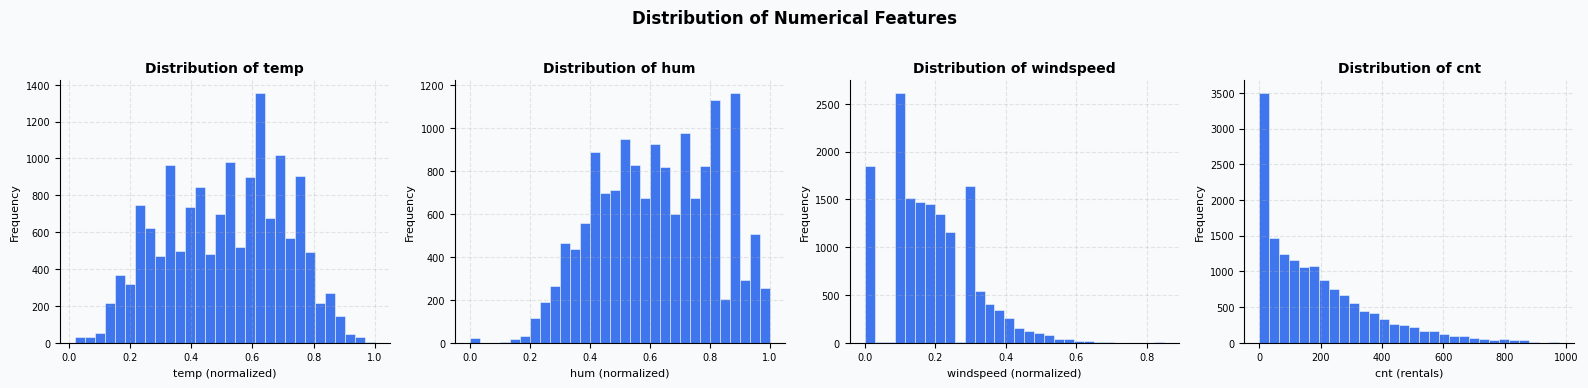

In [44]:
num_cols = ['temp', 'hum', 'windspeed', 'cnt']
labels   = ['temp (normalized)', 'hum (normalized)', 'windspeed (normalized)', 'cnt (rentals)']

fig, axes = plt.subplots(1, 4, figsize=(16, 3.8))
fig.patch.set_facecolor(BG)

for ax, col, label in zip(axes, num_cols, labels):
    ax.hist(train[col], bins=30, color=BLUE, edgecolor='white', linewidth=0.4, alpha=0.88)
    ax.set_title(f'Distribution of {col}', fontsize=10, fontweight='bold', pad=6)
    ax.set_xlabel(label, fontsize=8)
    ax.set_ylabel('Frequency', fontsize=8)

    ax.tick_params(labelsize=7)

plt.suptitle('Distribution of Numerical Features', fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("distr_variables_plot.png",
            dpi=300,
            facecolor=fig.get_facecolor(),
            bbox_inches='tight')
plt.show()

### 5.2 Categorical Feature Distributions <a id='5-2'></a>

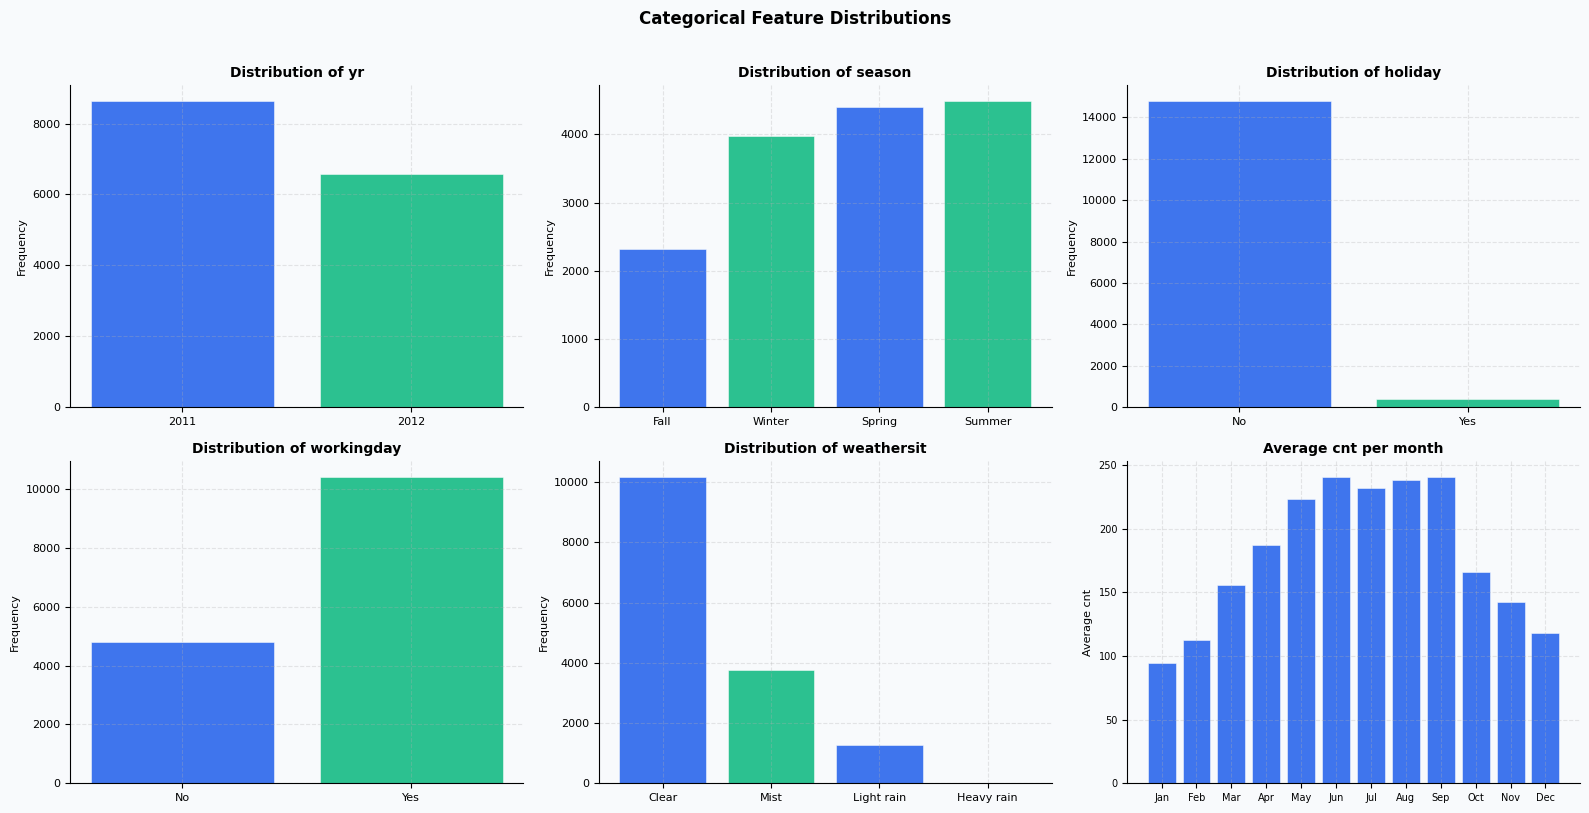

In [45]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.patch.set_facecolor(BG)
axes = axes.flatten()

cat_info = {
    'yr':         ({0:'2011', 1:'2012'},          'Distribution of yr'),
    'season':     ({0:'Fall',1:'Winter',2:'Spring',3:'Summer'}, 'Distribution of season'),
    'holiday':    ({0:'No', 1:'Yes'},              'Distribution of holiday'),
    'workingday': ({0:'No', 1:'Yes'},              'Distribution of workingday'),
    'weathersit': ({0:'Clear',1:'Mist',2:'Light rain',3:'Heavy rain'}, 'Distribution of weathersit'),
}

palette = [BLUE, '#10B981', BLUE, '#10B981', BLUE, '#10B981', BLUE, '#10B981']

for i, (col, (labels_map, title)) in enumerate(cat_info.items()):
    counts = train[col].value_counts().sort_index()
    xlabels = [labels_map.get(k, str(k)) for k in counts.index]
    colors  = palette[:len(counts)]
    axes[i].bar(xlabels, counts.values, color=colors, edgecolor='white', linewidth=0.4, alpha=0.88)
    axes[i].set_title(title, fontsize=10, fontweight='bold', pad=6)
    axes[i].set_ylabel('Frequency', fontsize=8)
    axes[i].tick_params(labelsize=8)

# Month average cnt
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
train_plot  = train.copy()
train_plot['mnth_orig'] = np.round(np.arctan2(train_plot['month_sin'],
                                               train_plot['month_cos']) * 6 / np.pi).astype(int) % 12
month_avg = train_plot.groupby('mnth_orig')['cnt'].mean()
axes[5].bar(month_names[:len(month_avg)], month_avg.values,
            color=BLUE, edgecolor='white', linewidth=0.4, alpha=0.88)
axes[5].set_title('Average cnt per month', fontsize=10, fontweight='bold', pad=6)
axes[5].set_ylabel('Average cnt', fontsize=8)
axes[5].tick_params(labelsize=7)

plt.suptitle('Categorical Feature Distributions', fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("distr_variables2_plot.png",
            dpi=300,
            facecolor=fig.get_facecolor(),
            bbox_inches='tight')
plt.show()


### 5.3 Hourly Rental Patterns by Season <a id='5-3'></a>

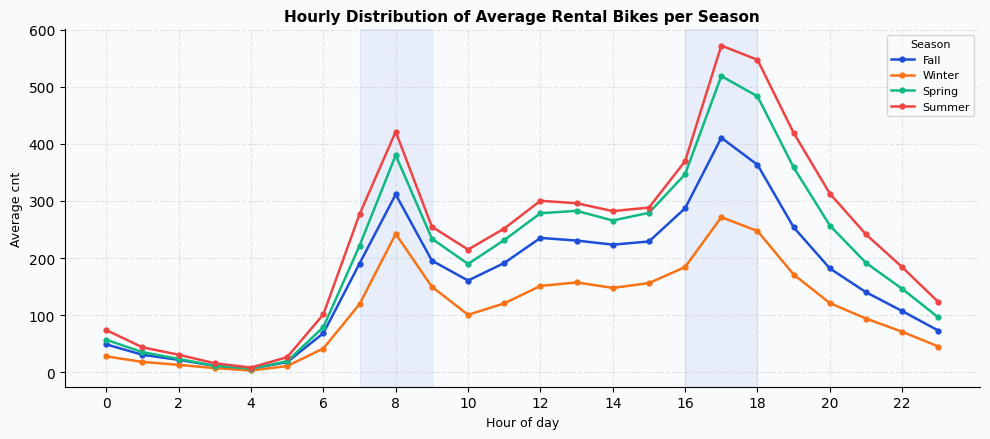

In [46]:
# Reconstruct hour from cyclic features
train_hr = train.copy()
train_hr['hr_approx'] = (np.round(
    np.arctan2(train_hr['hour_sin'], train_hr['hour_cos']) * 12 / np.pi
).astype(int)) % 24

colors_season = ['#1D4ED8', '#F97316', '#10B981', '#EF4444']
season_labels = {0: 'Fall', 1: 'Winter', 2: 'Spring', 3: 'Summer'}

fig, ax = plt.subplots(figsize=(10, 4.5))
fig.patch.set_facecolor(BG); ax.set_facecolor(BG)

for (s, label), c in zip(season_labels.items(), colors_season):
    sub = train_hr[train_hr['season'] == s].groupby('hr_approx')['cnt'].mean()
    ax.plot(sub.index, sub.values, marker='o', markersize=3.5, linewidth=1.8, label=label, color=c)

ax.axvspan(7, 9,   alpha=0.08, color=BLUE)
ax.axvspan(16, 18, alpha=0.08, color=BLUE)
ax.set_title('Hourly Distribution of Average Rental Bikes per Season',
             fontsize=11, fontweight='bold')
ax.set_xlabel('Hour of day', fontsize=9)
ax.set_ylabel('Average cnt', fontsize=9)
ax.set_xticks(range(0, 24, 2))
ax.legend(title='Season', fontsize=8, title_fontsize=8)
plt.tight_layout()
plt.savefig("hourly_distr_avg_cnt_plot.png",
            dpi=300,
            facecolor=fig.get_facecolor(),
            bbox_inches='tight')
plt.show()


### 5.4 Hourly Patterns: Workday vs Weekend / Holiday <a id='5-4'></a>

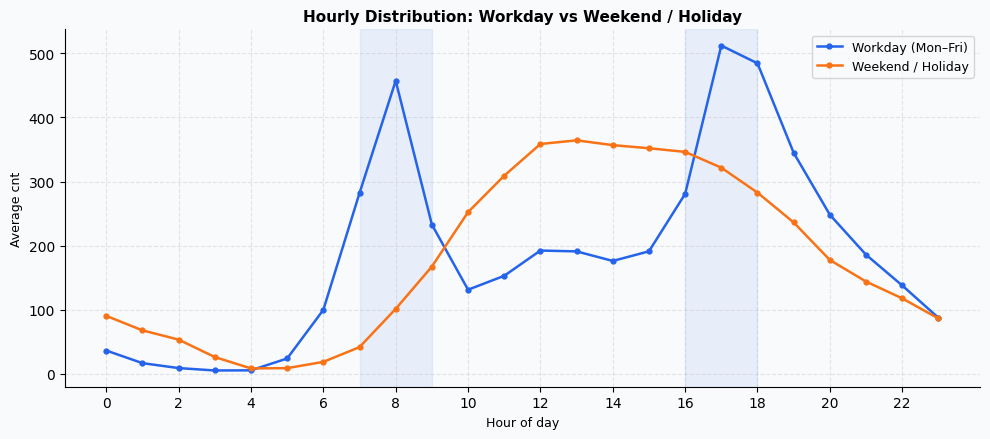

In [47]:
fig, ax = plt.subplots(figsize=(10, 4.5))
fig.patch.set_facecolor(BG); ax.set_facecolor(BG)

for wd, label, color in [(1, 'Workday (Mon–Fri)', BLUE),
                          (0, 'Weekend / Holiday', ORANGE)]:
    sub = train_hr[train_hr['workingday'] == wd].groupby('hr_approx')['cnt'].mean()
    ax.plot(sub.index, sub.values, marker='o', markersize=3.5, linewidth=1.8,
            label=label, color=color)

ax.axvspan(7, 9,   alpha=0.08, color=BLUE)
ax.axvspan(16, 18, alpha=0.08, color=BLUE)
ax.set_title('Hourly Distribution: Workday vs Weekend / Holiday',
             fontsize=11, fontweight='bold')
ax.set_xlabel('Hour of day', fontsize=9)
ax.set_ylabel('Average cnt', fontsize=9)
ax.set_xticks(range(0, 24, 2))
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("hourly_distr_workday_weekend_plot.png",
            dpi=300,
            facecolor=fig.get_facecolor(),
            bbox_inches='tight')
plt.show()


### 5.5 Average Rental Count per Month <a id='5-5'></a>

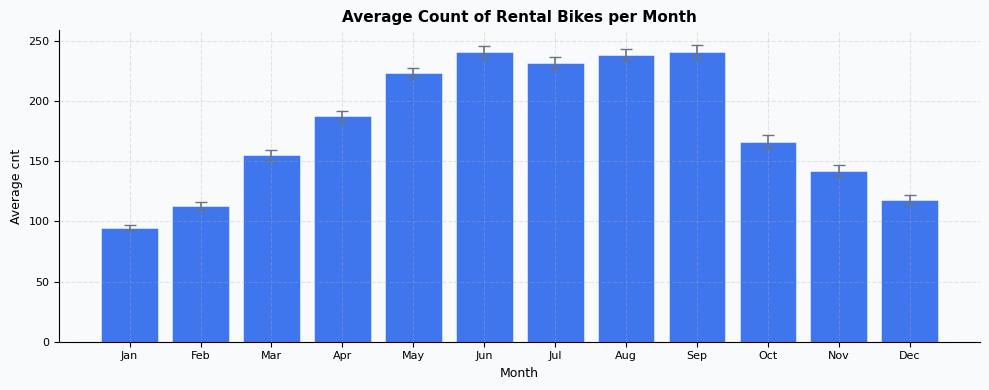

In [48]:
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

# Reconstruire le mois original à partir de month_sin et month_cos
train_plot = train.copy()

train_plot['mnth_orig'] = (
    np.round(
        np.arctan2(train_plot['month_sin'], train_plot['month_cos']) * 6 / np.pi
    ).astype(int) % 12
)

# Moyenne et écart-type du cnt par mois
month_avg_vals = (
    train_plot
    .groupby('mnth_orig')['cnt']
    .agg(['mean', 'std', 'count'])
    .reset_index()
    .sort_values('mnth_orig')
)

fig, ax = plt.subplots(figsize=(10, 4))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

ax.bar(
    month_names[:len(month_avg_vals)],
    month_avg_vals['mean'].values,
    color=BLUE,
    alpha=0.88,
    edgecolor='white',
    linewidth=0.4
)

ax.errorbar(
    month_names[:len(month_avg_vals)],
    month_avg_vals['mean'].values,
    yerr=month_avg_vals['std'].values / np.sqrt(month_avg_vals['count'].values),
    fmt='none',
    color=GRAY,
    capsize=4,
    linewidth=1.2
)

ax.set_title('Average Count of Rental Bikes per Month',
             fontsize=11, fontweight='bold')
ax.set_xlabel('Month', fontsize=9)
ax.set_ylabel('Average cnt', fontsize=9)
ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig("avg_cnt_mnth_plot.png",
            dpi=300,
            facecolor=fig.get_facecolor(),
            bbox_inches='tight')
plt.show()


### 5.6 Correlation with Target (cnt) <a id='5-6'></a>

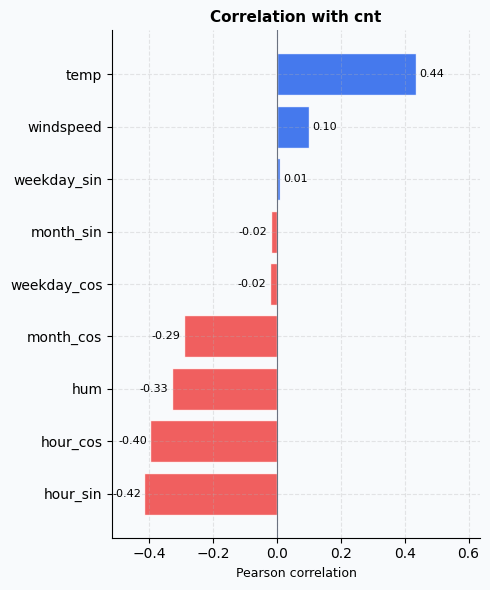

In [49]:
num_train = train.select_dtypes(include='number')
corr_cnt  = num_train.corr()['cnt'].drop('cnt').sort_values()

fig, ax = plt.subplots(figsize=(5, 6))
fig.patch.set_facecolor(BG); ax.set_facecolor(BG)

colors_bar = [BLUE if v >= 0 else '#EF4444' for v in corr_cnt.values]
bars = ax.barh(corr_cnt.index, corr_cnt.values, color=colors_bar, alpha=0.85, edgecolor='white')
ax.axvline(0, color=GRAY, linewidth=0.8)

for bar, val in zip(bars, corr_cnt.values):
    ax.text(val + (0.01 if val >= 0 else -0.01),
            bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}', va='center',
            ha='left' if val >= 0 else 'right', fontsize=8)

ax.set_title('Correlation with cnt', fontsize=11, fontweight='bold')
ax.set_xlabel('Pearson correlation', fontsize=9)
ax.set_xlim(corr_cnt.min() - 0.1, corr_cnt.max() + 0.2)
plt.tight_layout()
plt.savefig("correlation_plot.png",
            dpi=300,
            facecolor=fig.get_facecolor(),
            bbox_inches='tight')
plt.show()


### 5.7 Year Distribution of Counts (Violin Plot) <a id='5-7'></a>

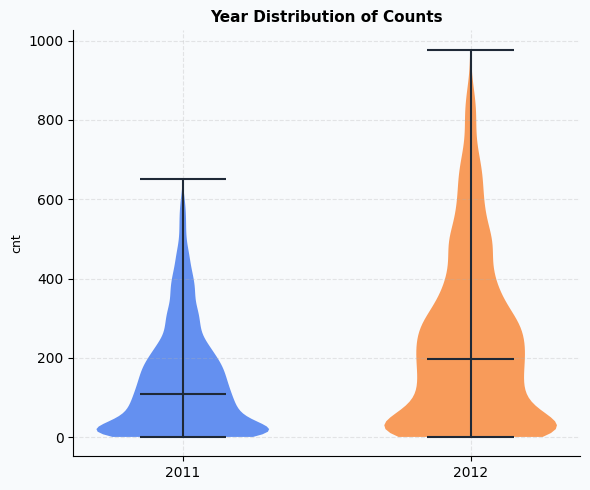

In [50]:
cnt_2011 = train.loc[train['yr'] == 0, 'cnt'].values
cnt_2012 = train.loc[train['yr'] == 1, 'cnt'].values

fig, ax = plt.subplots(figsize=(6, 5))
fig.patch.set_facecolor(BG); ax.set_facecolor(BG)

vp = ax.violinplot([cnt_2011, cnt_2012], positions=[0, 1],
                   showmedians=True, widths=0.6)
for body, color in zip(vp['bodies'], [BLUE, ORANGE]):
    body.set_facecolor(color); body.set_alpha(0.7)
for part in ['cmedians', 'cbars', 'cmins', 'cmaxes']:
    vp[part].set_color('#1F2937')

ax.set_xticks([0, 1]); ax.set_xticklabels(['2011', '2012'])
ax.set_title('Year Distribution of Counts', fontsize=11, fontweight='bold')
ax.set_ylabel('cnt', fontsize=9)
plt.tight_layout()
plt.savefig("violin_plot.png",
            dpi=300,
            facecolor=fig.get_facecolor(),
            bbox_inches='tight')
plt.show()


## 6. Modelling <a id='6'></a>

In [27]:
X = train.drop(columns=['cnt'])
Y = train['cnt']
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=SEED)
folds = KFold(n_splits=5, shuffle=True, random_state=SEED)
print(f'Train: {X_train.shape} | Test: {X_test.shape}')


Train: (12168, 14) | Test: (3042, 14)


### 6.1 Linear & Lasso Regression <a id='6-1'></a>

In [28]:
lr = LinearRegression()
lr.fit(X_train, Y_train)
lr_mae = mean_absolute_error(Y_test, lr.predict(X_test))
print(f'Linear Regression | Test MAE: {lr_mae:.2f}')

lasso_cv = LassoCV(alphas=np.logspace(0, 6, 100), cv=folds, max_iter=10_000)
lasso_cv.fit(X_train, Y_train)

mse_path  = lasso_cv.mse_path_.mean(axis=1)
std_path  = lasso_cv.mse_path_.std(axis=1)
best_idx  = np.argmin(mse_path)
threshold = mse_path[best_idx] + std_path[best_idx]
se_idx    = np.where(mse_path <= threshold)[0].max()
alpha_1se = lasso_cv.alphas_[se_idx]

lasso = Lasso(alpha=alpha_1se, max_iter=10_000)
lasso.fit(X_train, Y_train)
lasso_mae = mean_absolute_error(Y_test, lasso.predict(X_test))
print(f'Lasso (1-SE rule) | Test MAE: {lasso_mae:.2f} | Alpha: {alpha_1se:.4f}')
print(f'Zeroed features:  {X.columns[lasso.coef_ == 0].tolist()}')


Linear Regression | Test MAE: 91.09
Lasso (1-SE rule) | Test MAE: 91.31 | Alpha: 1.0000
Zeroed features:  ['holiday', 'hum', 'windspeed', 'weekday_sin']


/opt/anaconda3/envs/tfclean/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/tfclean/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/tfclean/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/tfclean/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/tfclean/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/tfclean/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarn

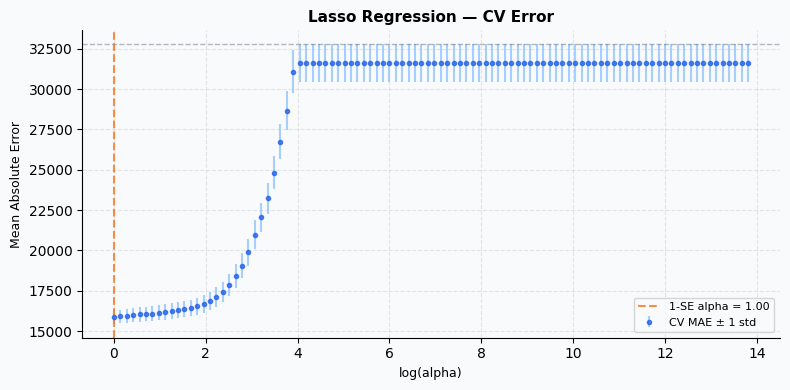

In [51]:
# Lasso CV path
fig, ax = plt.subplots(figsize=(8, 4))
fig.patch.set_facecolor(BG); ax.set_facecolor(BG)

ax.errorbar(np.log(lasso_cv.alphas_), mse_path, yerr=std_path,
            fmt='o', ms=3, color=BLUE, ecolor=BLUE2, alpha=0.8, label='CV MAE ± 1 std')
ax.axhline(mse_path[best_idx] + std_path[best_idx],
           linestyle='--', color=GRAY, alpha=0.5, linewidth=1)
ax.axvline(np.log(alpha_1se), linestyle='--', color=ORANGE,
           alpha=0.8, linewidth=1.5, label=f'1-SE alpha = {alpha_1se:.2f}')
ax.set_xlabel('log(alpha)', fontsize=9)
ax.set_ylabel('Mean Absolute Error', fontsize=9)
ax.set_title('Lasso Regression — CV Error', fontsize=11, fontweight='bold')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("lasso_plot.png",
            dpi=300,
            facecolor=fig.get_facecolor(),
            bbox_inches='tight')
plt.show()


### 6.2 Decision Tree <a id='6-2'></a>

In [30]:
tree = DecisionTreeRegressor(max_depth=5, random_state=SEED)
tree.fit(X_train, Y_train)
tree_mae = mean_absolute_error(Y_test, tree.predict(X_test))
print(f'Decision Tree (depth=5) | Test MAE: {tree_mae:.2f}')


Decision Tree (depth=5) | Test MAE: 63.76


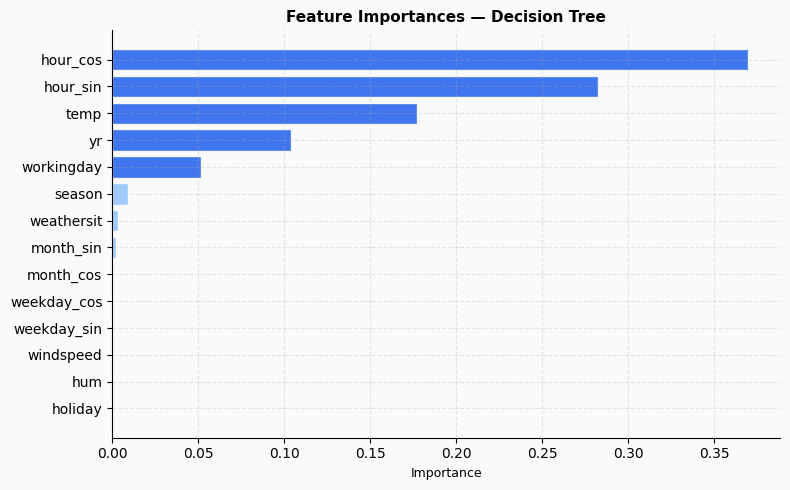

In [52]:
# Feature importances — Decision Tree
dt_feats = X.columns.tolist()
dt_imp   = tree.feature_importances_
order    = np.argsort(dt_imp)

colors_dt = [BLUE if v > 0.01 else BLUE2 for v in dt_imp[order]]

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor(BG); ax.set_facecolor(BG)

ax.barh([dt_feats[i] for i in order], dt_imp[order],
        color=colors_dt, edgecolor='white', alpha=0.88)
ax.set_title('Feature Importances — Decision Tree', fontsize=11, fontweight='bold')
ax.set_xlabel('Importance', fontsize=9)
plt.tight_layout()
plt.savefig("decision_tree_plot.png",
            dpi=300,
            facecolor=fig.get_facecolor(),
            bbox_inches='tight')
plt.show()


### 6.3 Random Forest <a id='6-3'></a>

In [32]:
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth':    [12, 15, 18],
    'max_features': [4, 5, 6]
}
rf_gs = GridSearchCV(RandomForestRegressor(random_state=SEED), rf_params,
                     cv=folds, scoring='neg_mean_absolute_error', n_jobs=-1, verbose=0)
rf_gs.fit(X_train, Y_train)
print('Best RF params:', rf_gs.best_params_)

rf = rf_gs.best_estimator_
rf_mae = mean_absolute_error(Y_test, rf.predict(X_test))
print(f'Random Forest | Test MAE: {rf_mae:.2f}')


/opt/anaconda3/envs/tfclean/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best RF params: {'max_depth': 18, 'max_features': 6, 'n_estimators': 300}
Random Forest | Test MAE: 25.40


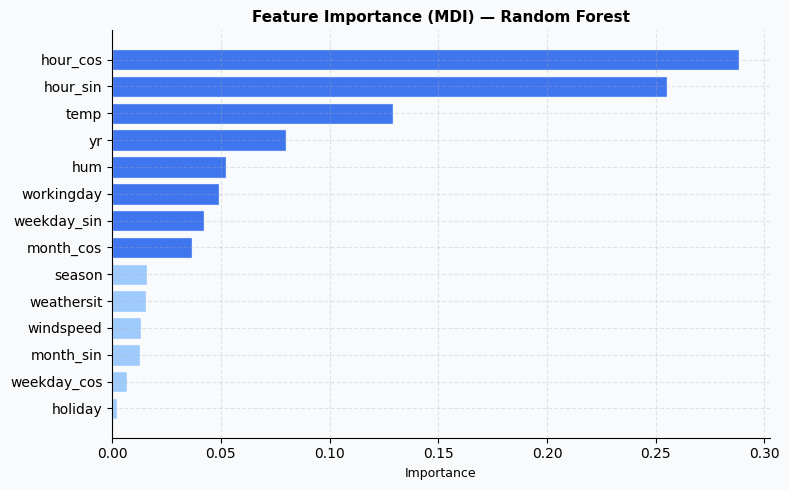

In [53]:
# Feature importances — Random Forest (MDI)
rf_imp  = rf.feature_importances_
rf_order = np.argsort(rf_imp)
colors_rf = [BLUE if v > 0.02 else BLUE2 for v in rf_imp[rf_order]]

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor(BG); ax.set_facecolor(BG)

ax.barh([dt_feats[i] for i in rf_order], rf_imp[rf_order],
        color=colors_rf, edgecolor='white', alpha=0.88)
ax.set_title('Feature Importance (MDI) — Random Forest', fontsize=11, fontweight='bold')
ax.set_xlabel('Importance', fontsize=9)
plt.tight_layout()
plt.savefig("RF_plot.png",
            dpi=300,
            facecolor=fig.get_facecolor(),
            bbox_inches='tight')
plt.show()


### 6.4 Gradient Boosting <a id='6-4'></a>

In [35]:
gb_params = {
    'n_estimators':  [500, 700, 1000],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth':     [3, 4, 5]
}
gb_gs = GridSearchCV(GradientBoostingRegressor(random_state=SEED), gb_params,
                     cv=folds, scoring='neg_mean_absolute_error', n_jobs=-1, verbose=0)
gb_gs.fit(X_train, Y_train)

cv_res      = gb_gs.cv_results_
mean_scores = -cv_res['mean_test_score']
std_scores  =  cv_res['std_test_score']
best_idx    = np.argmin(mean_scores)
threshold   = mean_scores[best_idx] + std_scores[best_idx]
simpler_idx = np.where(mean_scores <= threshold)[0].min()
print('Best params: ', gb_gs.best_params_)
print('1-SE params: ', cv_res['params'][simpler_idx])

gb = gb_gs.best_estimator_
gb_mae = mean_absolute_error(Y_test, gb.predict(X_test))
print(f'Gradient Boosting | Test MAE: {gb_mae:.2f}')


Best params:  {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 1000}
1-SE params:  {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 1000}
Gradient Boosting | Test MAE: 24.65


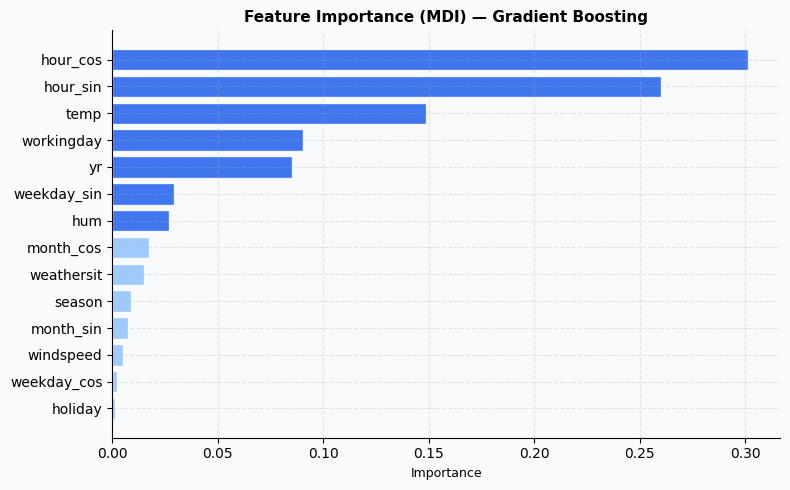

In [54]:
# Feature importances — Gradient Boosting (MDI)
gb_imp   = gb.feature_importances_
gb_order = np.argsort(gb_imp)
colors_gb = [BLUE if v > 0.02 else BLUE2 for v in gb_imp[gb_order]]

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor(BG); ax.set_facecolor(BG)

ax.barh([dt_feats[i] for i in gb_order], gb_imp[gb_order],
        color=colors_gb, edgecolor='white', alpha=0.88)
ax.set_title('Feature Importance (MDI) — Gradient Boosting', fontsize=11, fontweight='bold')
ax.set_xlabel('Importance', fontsize=9)
plt.tight_layout()
plt.savefig("GB_plot.png",
            dpi=300,
            facecolor=fig.get_facecolor(),
            bbox_inches='tight')
plt.show()


### 6.5 Support Vector Regression <a id='6-5'></a>

In [37]:
scaler    = StandardScaler()
X_tr_sc   = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

svr_params = {'kernel':['rbf'], 'C':[200,500,700], 'epsilon':[0.5,0.6,0.7], 'gamma':['auto']}
svr_gs = GridSearchCV(SVR(), svr_params, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1, verbose=0)
svr_gs.fit(X_tr_sc, Y_train)

svr_mae = mean_absolute_error(Y_test, svr_gs.best_estimator_.predict(X_test_sc))
print(f'SVR | Best params: {svr_gs.best_params_} | Test MAE: {svr_mae:.2f}')


SVR | Best params: {'C': 700, 'epsilon': 0.7, 'gamma': 'auto', 'kernel': 'rbf'} | Test MAE: 43.19


### 6.6 Deep Neural Network <a id='6-6'></a>

Architecture: **3 hidden layers (256 → 128 → 64)**, selected via 5-fold CV.  
Regularisation: LeakyReLU, Batch Normalisation, Dropout (0.2), Early Stopping, ReduceLROnPlateau.


In [38]:
cat_cols_dnn = ['season','yr','holiday','workingday','weathersit']
num_cols_dnn = ['temp','hum','windspeed',
                'hour_sin','hour_cos','weekday_sin','weekday_cos','month_sin','month_cos']

preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols_dnn),
    ('num', StandardScaler(), num_cols_dnn)
])

X_tr_d, X_val_d, Y_tr_d, Y_val_d = train_test_split(X, Y, test_size=0.2, random_state=SEED)
X_tr_pp  = preprocessor.fit_transform(X_tr_d)
X_val_pp = preprocessor.transform(X_val_d)

model = Sequential([
    Input(shape=(X_tr_pp.shape[1],)),
    Dense(256), LeakyReLU(alpha=0.1), BatchNormalization(), Dropout(0.2),
    Dense(128),  LeakyReLU(alpha=0.1), BatchNormalization(), Dropout(0.2),
    Dense(64),   LeakyReLU(alpha=0.1),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
]
history = model.fit(X_tr_pp, Y_tr_d,
                    validation_data=(X_val_pp, Y_val_d),
                    epochs=100, batch_size=32,
                    callbacks=callbacks, verbose=1)
_, val_mae_dnn = model.evaluate(X_val_pp, Y_val_d, verbose=0)
print(f'DNN | Validation MAE: {val_mae_dnn:.2f}')


/opt/anaconda3/envs/tfclean/lib/python3.10/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         6,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48,897 (191.00 KB)

 Trainable params: 48,129 (188.00 KB)

 Non-trainable params: 768 (3.00 KB)

Epoch 1/100
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 768us/step - loss: 22159.3145 - mae: 97.5716 - val_loss: 7523.6426 - val_mae: 57.9178 - learning_rate: 0.0010
Epoch 2/100
381/381 ━━━━━━━━━━━━━━━━━━━━ 0s 573us/step - loss: 6454.6636 - mae: 55.7608 - val_loss: 3193.9194 - val_mae: 39.7085 - learning_rate: 0.0010
Epoch 3/100
381/381 ━━━━━━━━━━━━━━━━━━━━ 0s 570us/step - loss: 5167.9985 - mae: 49.6995 - val_loss: 2692.8772 - val_mae: 35.6854 - learning_rate: 0.0010
Epoch 4/100
381/381 ━━━━━━━━━━━━━━━━━━━━ 0s 575us/step - loss: 4649.8013 - mae: 46.8611 - val_loss: 2330.1597 - val_mae: 32.9005 - learning_rate: 0.0010
Epoch 5/100
381/381 ━━━━━━━━━━━━━━━━━━━━ 0s 577us/step - loss: 4216.7651 - mae: 44.6977 - val_loss: 2217.8372 - val_mae: 31.8708 - learning_rate: 0.0010
Epoch 6/100
381/381 ━━━━━━━━━━━━━━━━━━━━ 0s 578us/step - loss: 4025.3672 - mae: 43.5874 - val_loss: 2077.5520 - val_mae: 30.5490 - learning_rate: 0.0010
Epoch 7/100
381/381 ━━━━━━━━━━━━━━━━━━━━ 0s 580us/step - loss: 3939.7034 - mae: 4

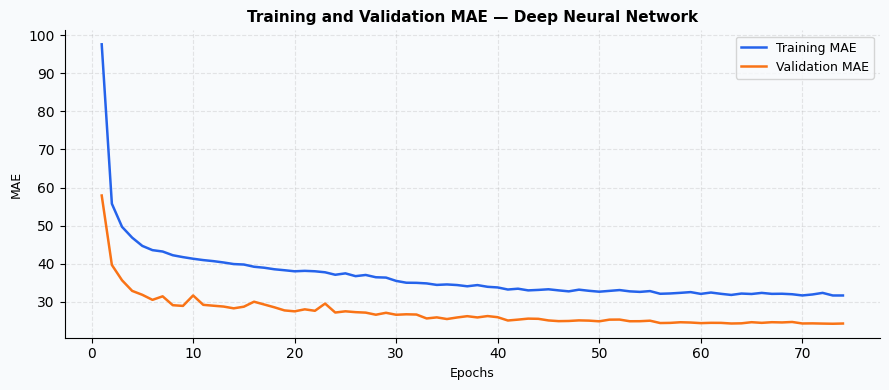

In [55]:
# Training & Validation MAE curve
epochs_range = range(1, len(history.history['mae']) + 1)

fig, ax = plt.subplots(figsize=(9, 4))
fig.patch.set_facecolor(BG); ax.set_facecolor(BG)

ax.plot(epochs_range, history.history['mae'],     color=BLUE,   linewidth=1.8, label='Training MAE')
ax.plot(epochs_range, history.history['val_mae'], color=ORANGE, linewidth=1.8, label='Validation MAE')
ax.set_title('Training and Validation MAE — Deep Neural Network',
             fontsize=11, fontweight='bold')
ax.set_xlabel('Epochs', fontsize=9)
ax.set_ylabel('MAE', fontsize=9)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("DNN_plot.png",
            dpi=300,
            facecolor=fig.get_facecolor(),
            bbox_inches='tight')
plt.show()


## 7. Results Summary <a id='7'></a>

In [56]:
results = {
    'Linear Regression':   {'Test MAE': 91.09, 'Kaggle MAE': None},
    'Lasso Regression':    {'Test MAE': 91.31, 'Kaggle MAE': None},
    'Decision Tree':       {'Test MAE': 63.76, 'Kaggle MAE': None},
    'Random Forest':       {'Test MAE': 25.40, 'Kaggle MAE': 54.37},
    'Gradient Boosting':   {'Test MAE': 24.65, 'Kaggle MAE': 43.32},
    'SVR (RBF kernel)':    {'Test MAE': 43.19, 'Kaggle MAE': 65.85},
    'Deep Neural Network': {'Test MAE': 24.39, 'Kaggle MAE': 35.75},
}
results_df = pd.DataFrame(results).T
print(results_df.to_string())


                     Test MAE  Kaggle MAE
Linear Regression       91.09         NaN
Lasso Regression        91.31         NaN
Decision Tree           63.76         NaN
Random Forest           25.40       54.37
Gradient Boosting       24.65       43.32
SVR (RBF kernel)        43.19       65.85
Deep Neural Network     24.39       35.75


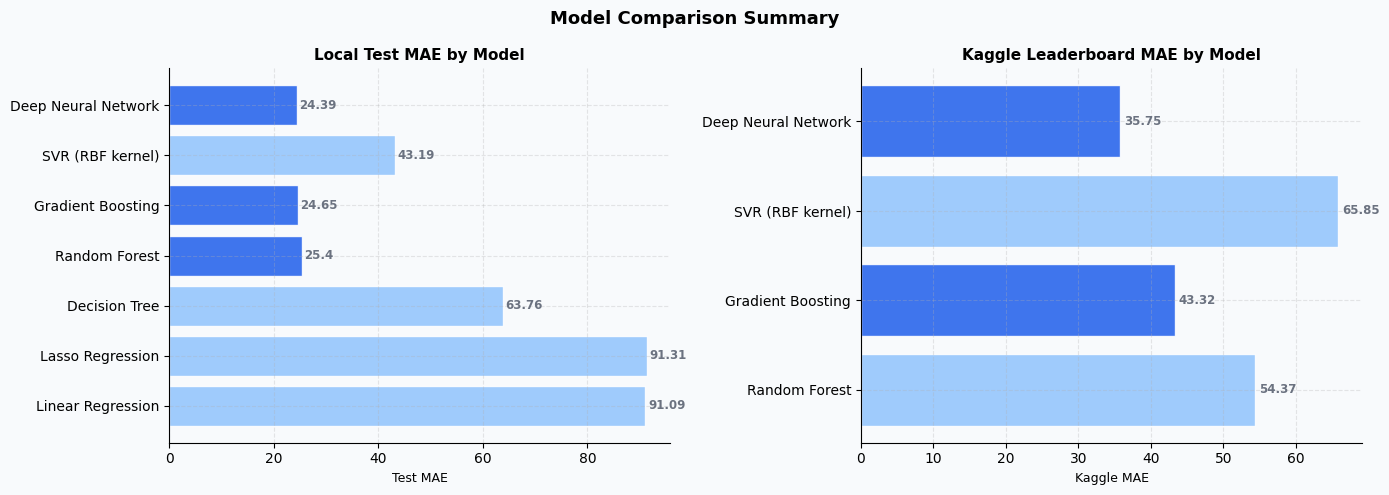

In [58]:
models_local  = list(results.keys())
mae_local     = [results[m]['Test MAE'] for m in models_local]

models_kaggle = [m for m in results if results[m]['Kaggle MAE'] is not None]
mae_kaggle    = [results[m]['Kaggle MAE'] for m in models_kaggle]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(BG)
for ax in axes: ax.set_facecolor(BG)

# Local test MAE
colors_l = [BLUE2 if v > 40 else BLUE for v in mae_local]
axes[0].barh(models_local, mae_local, color=colors_l, edgecolor='white', alpha=0.88)
for i, v in enumerate(mae_local):
    axes[0].text(v + 0.5, i, f'{v}', va='center', fontsize=8.5, fontweight='bold', color=GRAY)
axes[0].set_title('Local Test MAE by Model', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Test MAE', fontsize=9)

# Kaggle leaderboard MAE
colors_k = [BLUE2 if v > 50 else BLUE for v in mae_kaggle]
axes[1].barh(models_kaggle, mae_kaggle, color=colors_k, edgecolor='white', alpha=0.88)
for i, v in enumerate(mae_kaggle):
    axes[1].text(v + 0.5, i, f'{v}', va='center', fontsize=8.5, fontweight='bold', color=GRAY)
axes[1].set_title('Kaggle Leaderboard MAE by Model', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Kaggle MAE', fontsize=9)

plt.suptitle('Model Comparison Summary', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("model_comparison_plot.png",
            dpi=300,
            facecolor=fig.get_facecolor(),
            bbox_inches='tight')
plt.show()


68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 293us/step
train_dates: 15210 | Y: 15210
test_dates:  2168  | preds: 2168


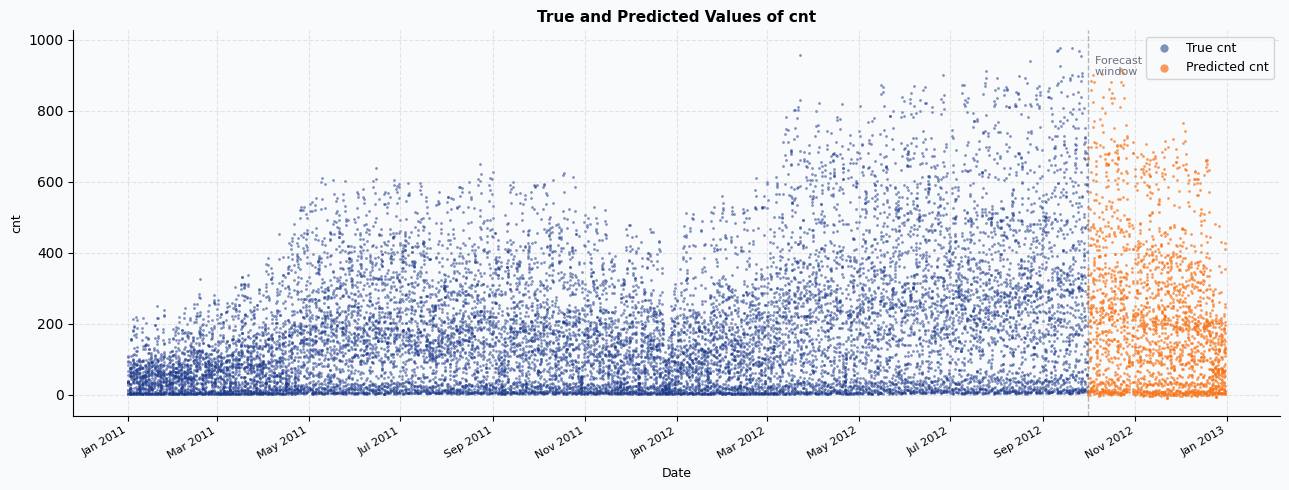

In [62]:
import matplotlib.dates as mdates

# Recharger les dates sans dropna — aligner directement sur l'index de Y
train_raw = pd.read_csv('train.csv')
test_raw  = pd.read_csv('test.csv')

# Utiliser l'index de Y pour récupérer les dates correspondantes
train_dates = pd.to_datetime(train_raw.loc[Y.index, 'dteday']).values
test_dates  = pd.to_datetime(test_raw['dteday']).values

# Prédictions DNN
test_pp          = preprocessor.transform(test)
test_predictions = model.predict(test_pp).flatten()

# Vérification des tailles avant de plotter
print(f'train_dates: {len(train_dates)} | Y: {len(Y)}')
print(f'test_dates:  {len(test_dates)}  | preds: {len(test_predictions)}')

fig, ax = plt.subplots(figsize=(13, 5))
fig.patch.set_facecolor(BG); ax.set_facecolor(BG)

ax.scatter(train_dates, Y.values,         color='#1E3A8A', s=4, alpha=0.55,
           label='True cnt',       linewidths=0)
ax.scatter(test_dates,  test_predictions, color=ORANGE,    s=4, alpha=0.70,
           label='Predicted cnt',  linewidths=0)

# Séparateur observé / forecast
ax.axvline(test_dates[0], color=GRAY, linewidth=1, linestyle='--', alpha=0.5)
ax.text(test_dates[0], ax.get_ylim()[1] * 0.93,
        '  Forecast\n  window', fontsize=8, color=GRAY, va='top')

# Axe X : mois + année
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30, ha='right', fontsize=8)

ax.set_title('True and Predicted Values of cnt', fontsize=11, fontweight='bold')
ax.set_xlabel('Date', fontsize=9)
ax.set_ylabel('cnt', fontsize=9)
ax.legend(fontsize=9, markerscale=3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('DNN_prediction_plot.png', dpi=300,
            facecolor=fig.get_facecolor(), bbox_inches='tight')
plt.show()